# VBPI vs. MCMC on rooted **time trees**

This notebook compares two approaches to Bayesian phylogenetic inference in
TreeFlow, on a small simulated dataset where the answer can be checked. Both work
on **rooted, ultrametric time trees**: the tree is parameterised by internal-node
*heights* (times), unconstrained through TreeFlow's node-height-ratio transform,
with a **coalescent** prior over those times.

1. **VBPI** (`treeflow.vbpi`) — the topology posterior is a **subsplit Bayesian
   network** (a conditional-clade / subsplit distribution on a compressed
   pointer-array support; with the complete *enumerated* support of a small taxon
   set it spans every rooted topology). Node heights get an amortised Gaussian in
   the unconstrained ratio space
   (`NodeHeightRatioModel` → `NodeHeightRatioChainBijector`), and the whole thing
   is trained with the **VIMCO** multi-sample gradient estimator.

2. **Metropolis-Hastings MCMC** (`treeflow.vbpi.mcmc`) — a Metropolis-within-Gibbs
   sampler alternating rooted **nearest-neighbour-interchange (NNI)** topology
   moves (a symmetric proposal that carries the unconstrained height latent, so
   the reattached tree is always a valid time tree) with a random-walk update of
   the heights. The topology move is wrapped in TensorFlow Probability's
   `TransitionKernel` abstraction, exactly as TreeFlow's HMC code is.

Both target the *same* joint posterior `p(T, times | D) ∝ p(D | T, times)
· p_coalescent(T, times)` under Jukes-Cantor, scored in rooted-tree space with
TreeFlow's native likelihood op, the JC substitution model, and the
`ConstantCoalescent` prior. We compare the two **topology marginals**.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from treeflow import DEFAULT_FLOAT_DTYPE_TF
from treeflow.vbpi import (
    SubsplitSupport,
    SubsplitBayesianNetwork,
    NodeHeightRatioModel,
    all_rooted_parent_indices,
    vimco_surrogate,
    build_time_tree,
    coalescent_prior,
    time_tree_jc_log_likelihood,
    sample_phylogenetic_time_trees,
)
from treeflow.vbpi.timetree import as_topology
from treeflow.vbpi.clade import node_clades
from treeflow.vbpi.mcmc import canonicalize_parent_indices
from treeflow.acceleration.native import is_available as native_available

tf.random.set_seed(0)
rng = np.random.default_rng(20240717)
DTYPE = DEFAULT_FLOAT_DTYPE_TF.as_numpy_dtype

I0000 00:00:1784320241.253588   14572 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784320241.259170   14572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784320241.857150   14572 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784320245.494708   14572 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784320245.497942   14572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Simulate a small true time tree and an alignment

`n = 5` taxa gives `(2n-3)!! = 105` rooted topologies (`15` unrooted) — small
enough to enumerate the SBN's complete support and score every topology exactly.
The true tree is ultrametric: leaves at time 0, internal nodes at increasing
times.

In [2]:
def random_rooted_parent_indices(n, rng):
    node_count = 2 * n - 1
    parent = np.full(node_count - 1, -1, dtype=np.int32)
    active = list(range(n)); nxt = n
    while len(active) > 1:
        i = active.pop(rng.integers(len(active)))
        j = active.pop(rng.integers(len(active)))
        parent[i] = nxt; parent[j] = nxt; active.append(nxt); nxt += 1
    return parent

def simulate_jc_alignment(parent, branch, n_sites, n, rng):
    def P(t):
        r = np.exp(-4/3 * t)
        return np.where(np.eye(4, dtype=bool), .25 + .75*r, .25 - .25*r)
    node_count = 2 * n - 1
    states = np.full((node_count, n_sites), -1, dtype=int)
    states[node_count - 1] = rng.integers(0, 4, size=n_sites)   # root
    for node in range(node_count - 2, -1, -1):                  # parents first
        probs = P(branch[node])[states[parent[node]]]
        u = rng.random((n_sites, 1))
        states[node] = (np.cumsum(probs, 1) > u).argmax(1)
    return np.eye(4)[states[:n]].astype(DTYPE)

N_TAXA = 5
N_SITES = 300
POP_SIZE = 0.15     # constant-coalescent effective population size
CLOCK_RATE = 1.0    # strict clock: time == expected substitutions

true_tree = random_rooted_parent_indices(N_TAXA, rng)
node_count = 2 * N_TAXA - 1
# Ultrametric heights: leaves at 0, internal nodes at increasing times.
true_heights = np.concatenate(
    [np.zeros(N_TAXA), np.sort(rng.uniform(0.05, 0.25, N_TAXA - 1))]).astype(DTYPE)
true_branch = np.array(
    [true_heights[true_tree[i]] - true_heights[i] for i in range(node_count - 1)])
leaf_partials = simulate_jc_alignment(true_tree, CLOCK_RATE * true_branch,
                                      N_SITES, N_TAXA, rng)

print("true tree parent_indices:", true_tree.tolist())
print("true internal node heights:", np.round(true_heights[N_TAXA:], 3).tolist())
print("true tree clades:", sorted((tuple(sorted(c)) for c in node_clades(true_tree, N_TAXA)), key=len))
print("alignment shape [taxa, sites, states]:", leaf_partials.shape)

true tree parent_indices: [5, 6, 7, 8, 5, 6, 7, 8]
true internal node heights: [0.074, 0.221, 0.234, 0.25]
true tree clades: [(0,), (1,), (2,), (3,), (4,), (0, 4), (0, 1, 4), (0, 1, 2, 4), (0, 1, 2, 3, 4)]
alignment shape [taxa, sites, states]: (5, 300, 4)


## 2. Enumerate the rooted topologies and build the SBN support

The **pointer-array support** is built from *all* rooted topologies, so the SBN
can represent any of them (an *enumerated* subsplit distribution).

In [3]:
all_topos = all_rooted_parent_indices(N_TAXA)
support = SubsplitSupport.from_topologies(all_topos, N_TAXA)
print(support)
print("pointer-array: num_clades =", support.num_clades,
      "| num candidate subsplits (SBN parameters) =", support.num_candidates)

def canon_key(parent):
    return tuple(canonicalize_parent_indices(parent, N_TAXA)[0].tolist())

topo_index = {canon_key(t): i for i, t in enumerate(all_topos)}
true_topo_i = topo_index[canon_key(true_tree)]
cand_indices = support.batch_topology_candidate_indices(all_topos)  # [n_topos, n-1]
print("number of enumerated rooted topologies:", len(all_topos))

SubsplitSupport(taxon_count=5, num_clades=31, num_candidates=90)
pointer-array: num_clades = 31 | num candidate subsplits (SBN parameters) = 90
number of enumerated rooted topologies: 105


## 3. The generative model and the VBPI variational family

`p(T, times | D) ∝ p(D | T, times) · p_coalescent(T, times)`. The coalescent is
the *joint* tree prior — it already scores both the topology and the node times,
so there is no separate topology prior. The variational family is `q(T)
q(times | T)`: the SBN over topologies and a diagonal Gaussian over the
unconstrained node-height ratios (per-clade parameters, shared across
topologies).

In [4]:
sbn = SubsplitBayesianNetwork(support)            # q(T)
height_model = NodeHeightRatioModel(support, init_loc=-1.5, init_scale=0.3)  # q(times | T)
coalescent = coalescent_prior(N_TAXA, tf.constant(POP_SIZE, dtype=DEFAULT_FLOAT_DTYPE_TF))
leaf_partials_t = tf.constant(leaf_partials)
USE_NATIVE = native_available()  # resolve once (avoids a graph-time file check)

E0000 00:00:1784320249.251325   14572 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 4. Train VBPI with VIMCO

Each step: sample `K` topologies from the SBN (native sampler), reparameterise
their node heights through the ratio transform, score the JC likelihood (native
op) and the coalescent prior (both differentiable in the heights), form the
importance weights, and take a VIMCO gradient step. The topology `log q(T)` stays
attached in the weights so VIMCO's control variate supplies the discrete-sampling
gradient.

ELBO: start -1630.54 -> end -1440.15


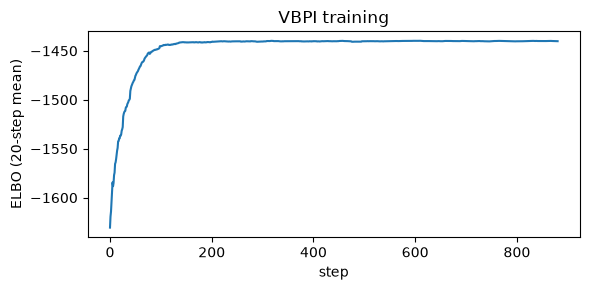

In [5]:
K = 10
N_STEPS = 900
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)
variables = [sbn.logits, height_model.loc, height_model.scale_param]

# The loss and its gradients are one tf.function (traced once, then called with
# each step's sampled topology index tensors) -- eager evaluation is ~30x slower.
@tf.function
def loss_and_grads(cand, node_clade_ids, topologies, height_seed):
    with tf.GradientTape() as tape:
        log_q_topology = sbn.log_prob(cand)                                      # [K]
        node_heights, log_q_heights = height_model.sample_and_log_prob(
            node_clade_ids, topologies, seed=height_seed)                        # [K, n-1], [K]
        log_lik = tf.stack([
            time_tree_jc_log_likelihood(topologies[k], leaf_partials_t,
                                        node_heights[k], clock_rate=CLOCK_RATE,
                                        use_native=USE_NATIVE)
            for k in range(K)])                                                  # [K]
        log_p_tree = tf.stack([
            coalescent.log_prob(build_time_tree(topologies[k], node_heights[k]))
            for k in range(K)])                                                  # [K]
        log_weights = log_lik + log_p_tree - log_q_topology - log_q_heights      # [K]
        obj = vimco_surrogate(log_weights[tf.newaxis], log_q_topology[tf.newaxis])
        loss = -tf.reduce_mean(obj.surrogate)
    return obj.elbo, tape.gradient(loss, variables)

def vbpi_step(step_seed):
    samples = sbn.sample_topologies(K, seed=step_seed, use_native="auto")
    cand = tf.constant(samples.candidate_indices.astype(np.int64))
    node_clade_ids = tf.constant(samples.node_clade_ids)
    topologies = tuple(as_topology(samples.parent_indices[k]) for k in range(K))
    elbo, grads = loss_and_grads(
        cand, node_clade_ids, topologies, tf.constant([step_seed, 101], tf.int32))
    optimizer.apply_gradients(zip(grads, variables))
    return float(tf.reduce_mean(elbo))

elbo_trace = [vbpi_step(s) for s in range(1, N_STEPS + 1)]
print("ELBO: start %.2f -> end %.2f" % (np.mean(elbo_trace[:20]), np.mean(elbo_trace[-20:])))

plt.figure(figsize=(6, 3))
plt.plot(np.convolve(elbo_trace, np.ones(20)/20, mode="valid"))
plt.xlabel("step"); plt.ylabel("ELBO (20-step mean)"); plt.title("VBPI training")
plt.tight_layout(); plt.show()

## 5. Read off the VBPI topology posterior `q(T)`

Because the support is complete, `q(T)` is a proper distribution over all 105
rooted topologies and we can evaluate every one.

In [6]:
vbpi_q = np.exp(sbn.log_prob(tf.constant(cand_indices)).numpy())
print("sum q(T) over all topologies =", vbpi_q.sum())
print("top VBPI topologies (index, q):")
for i in np.argsort(vbpi_q)[::-1][:5]:
    print("  %4d  q=%.4f  %s" % (i, vbpi_q[i], "<-- TRUE" if i == true_topo_i else ""))

sum q(T) over all topologies = 1.0
top VBPI topologies (index, q):
    53  q=0.6778  
    74  q=0.0622  
    51  q=0.0307  
    52  q=0.0265  
    54  q=0.0163  


## 6. Metropolis-Hastings MCMC over the same posterior

The joint sampler alternates rooted-NNI topology moves (carrying the height
latent) with random-walk height updates, under the same coalescent prior and JC
likelihood. We tally how often each rooted topology is visited.

In [7]:
mcmc = sample_phylogenetic_time_trees(
    leaf_partials, N_TAXA,
    num_results=25000, num_burnin_steps=5000,
    prior="coalescent", pop_size=POP_SIZE, clock_rate=CLOCK_RATE,
    height_proposal_scale=0.25, seed=3)
print("topology accept rate: %.3f | height accept rate: %.3f"
      % (mcmc.topology_accept_rate, mcmc.height_accept_rate))

mcmc_counts = np.zeros(len(all_topos))
for s in mcmc.topologies:
    mcmc_counts[topo_index[canon_key(s)]] += 1
mcmc_freq = mcmc_counts / mcmc_counts.sum()
print("top MCMC topologies (index, freq):")
for i in np.argsort(mcmc_freq)[::-1][:5]:
    print("  %4d  freq=%.4f  %s" % (i, mcmc_freq[i], "<-- TRUE" if i == true_topo_i else ""))

topology accept rate: 0.346 | height accept rate: 0.222


top MCMC topologies (index, freq):
    53  freq=0.2590  
    68  freq=0.2559  <-- TRUE
    86  freq=0.2134  
    48  freq=0.0634  
    65  freq=0.0586  


## 7. Compare the two topology posteriors

Both methods put their mass on rootings of the true tree. But note a real,
expected difference: Jukes-Cantor is reversible, so the *likelihood* cannot
locate the root and the posterior over **rooted** topologies is multimodal —
several rootings of the true tree have comparable probability, which MCMC samples
in proportion. VBPI minimises the *exclusive* KL `KL(q‖p)`, which is
**mode-seeking**, so it tends to concentrate on a single one of those rootings
rather than spreading over them. Expect the true-tree rootings to dominate both,
with MCMC spread across them and VBPI concentrated on one.

total-variation distance |q - MCMC| / 2 = 0.6829
correlation on non-negligible topologies = 0.5910
VBPI q(true) = 0.0037 | MCMC freq(true) = 0.2559


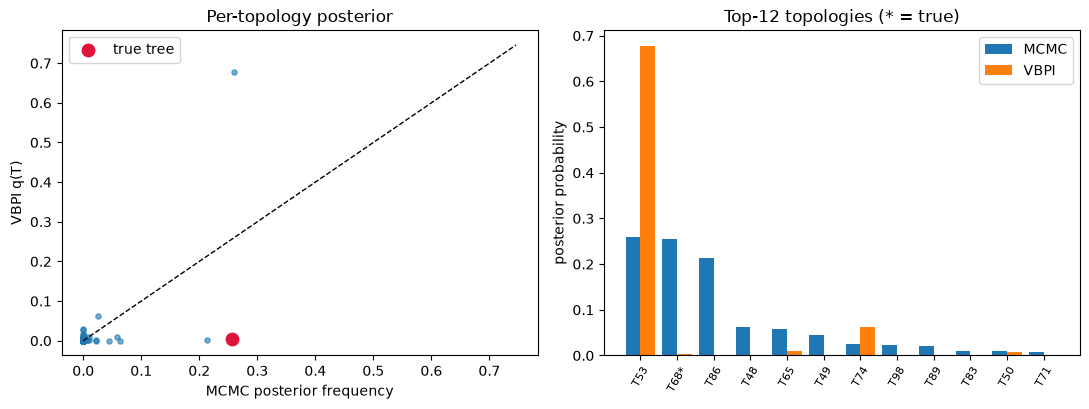

In [8]:
tv = 0.5 * np.abs(vbpi_q - mcmc_freq).sum()
mass = vbpi_q > 1e-3
corr = np.corrcoef(vbpi_q[mass], mcmc_freq[mass])[0, 1] if mass.sum() > 1 else float("nan")
print("total-variation distance |q - MCMC| / 2 = %.4f" % tv)
print("correlation on non-negligible topologies = %.4f" % corr)
print("VBPI q(true) = %.4f | MCMC freq(true) = %.4f" % (vbpi_q[true_topo_i], mcmc_freq[true_topo_i]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
lim = max(vbpi_q.max(), mcmc_freq.max()) * 1.1
ax[0].plot([0, lim], [0, lim], "k--", lw=1)
ax[0].scatter(mcmc_freq, vbpi_q, s=14, alpha=0.6)
ax[0].scatter(mcmc_freq[true_topo_i], vbpi_q[true_topo_i], s=80,
              color="crimson", label="true tree", zorder=5)
ax[0].set_xlabel("MCMC posterior frequency"); ax[0].set_ylabel("VBPI q(T)")
ax[0].set_title("Per-topology posterior"); ax[0].legend()

top = np.argsort(mcmc_freq)[::-1][:12]
x = np.arange(len(top)); w = 0.4
ax[1].bar(x - w/2, mcmc_freq[top], w, label="MCMC")
ax[1].bar(x + w/2, vbpi_q[top], w, label="VBPI")
ax[1].set_xticks(x)
ax[1].set_xticklabels(["T%d%s" % (i, "*" if i == true_topo_i else "") for i in top],
                      rotation=60, fontsize=8)
ax[1].set_ylabel("posterior probability")
ax[1].set_title("Top-12 topologies (* = true)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Aggregate to *unrooted* topologies

Jukes-Cantor is reversible, so the likelihood cannot locate the root; the
coalescent prior does break the symmetry a little (it prefers some rootings), but
much of the posterior spread across a tree's rootings remains. Collapsing rooted
topologies to their unrooted split set gives a sharper comparison of what the
data actually determine.

unrooted TV distance = 0.2127
VBPI(true unrooted) = 0.6837 | MCMC(true unrooted) = 0.8136


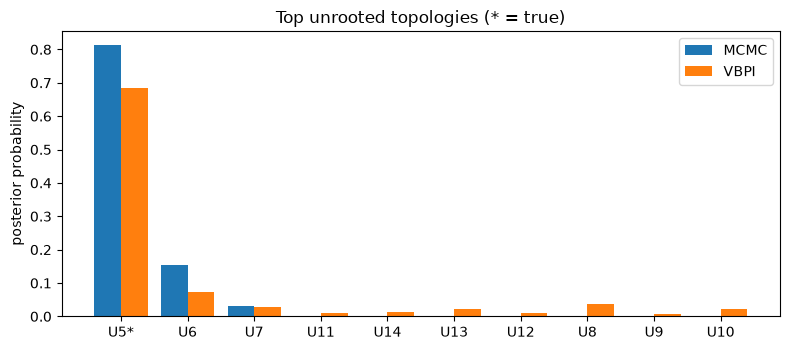

In [9]:
def unrooted_signature(parent):
    full = frozenset(range(N_TAXA))
    return frozenset(
        frozenset({c, full - c})
        for c in node_clades(parent, N_TAXA)
        if 2 <= len(c) <= N_TAXA - 2)

sig_ids, sigs = {}, []
def sig_id(parent):
    s = unrooted_signature(parent)
    if s not in sig_ids:
        sig_ids[s] = len(sigs); sigs.append(s)
    return sig_ids[s]

vbpi_unrooted, mcmc_unrooted = {}, {}
for i, t in enumerate(all_topos):
    sid = sig_id(t)
    vbpi_unrooted[sid] = vbpi_unrooted.get(sid, 0.0) + vbpi_q[i]
    mcmc_unrooted[sid] = mcmc_unrooted.get(sid, 0.0) + mcmc_freq[i]
true_sid = sig_id(true_tree)

sids = sorted(vbpi_unrooted, key=lambda s: -mcmc_unrooted.get(s, 0))
v = np.array([vbpi_unrooted[s] for s in sids])
m = np.array([mcmc_unrooted.get(s, 0.0) for s in sids])
print("unrooted TV distance = %.4f" % (0.5 * np.abs(v - m).sum()))
print("VBPI(true unrooted) = %.4f | MCMC(true unrooted) = %.4f"
      % (vbpi_unrooted[true_sid], mcmc_unrooted.get(true_sid, 0.0)))

top = np.argsort(m)[::-1][:10]
x = np.arange(len(top)); w = 0.4
plt.figure(figsize=(8, 3.6))
plt.bar(x - w/2, m[top], w, label="MCMC")
plt.bar(x + w/2, v[top], w, label="VBPI")
plt.xticks(x, ["U%d%s" % (sids[j], "*" if sids[j] == true_sid else "") for j in top])
plt.ylabel("posterior probability")
plt.title("Top unrooted topologies (* = true)"); plt.legend()
plt.tight_layout(); plt.show()

## Conclusions

* On **time trees** (node heights unconstrained through the node-height-ratio
  transform, with a coalescent prior), VBPI's enumerated **subsplit Bayesian
  network** and the **NNI Metropolis-Hastings** sampler recover the same
  *unrooted* topology posterior — both concentrate on the simulated true tree,
  and the unrooted total-variation distance is small.
* At the **rooted** level they differ in a way that is expected, not a bug:
  because Jukes-Cantor cannot locate the root, the rooted posterior is multimodal
  over the true tree's rootings. MCMC (asymptotically exact) samples those
  rootings in proportion, while VBPI's **mode-seeking** exclusive-KL objective
  collapses onto one of them. This is the textbook mean-field-VI-vs-MCMC
  trade-off, surfaced cleanly by the rooting symmetry.
* Everything ran in **rooted time-tree space** and reused TreeFlow's existing
  pieces — the Jukes-Cantor model, the native phylogenetic-likelihood op, the
  `NodeHeightRatioChainBijector` unconstraining transform, the `ConstantCoalescent`
  prior, and the TFP `TransitionKernel` MCMC abstraction.